## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import missingno
import re

from sklearn.impute import KNNImputer
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr
import pickle

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../../Modules")
sys.path.insert(0, "../../../../Mamoth")

from utils import *
from Neural_Network_Module import give_predictions, Dataset


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
utils = importr('utils')
base = importr('base')
dismo = importr('dismo')
utils.chooseCRANmirror(ind=41)

<rpy2.rinterface_lib.sexp.NULLType object at 0x000001E71B8B4440> [RTYPES.NILSXP]

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'
#NUTS2_EL = 'κεντρικης μακεδονιας'

In [4]:
timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_NUTS3_2010-2022_filled_meantemps.csv', encoding=enc)
wnv_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Cases_NUTS3_2010-2022.csv', encoding=enc)

In [5]:
timeline_file.head()

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall
0,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.742560,39.293760,2010-01-01,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.374623
1,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.742560,39.293760,2010-01-02,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.121427
2,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.742560,39.293760,2010-01-03,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13895.000000,NaN,NaN,NaN,NaN,13895.000000,NaN,NaN,NaN,0.081799
3,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.742560,39.293760,2010-01-04,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13895.000000,NaN,NaN,NaN,NaN,13895.000000,NaN,NaN,NaN,1.822118
4,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.742560,39.293760,2010-01-05,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13895.000000,NaN,NaN,NaN,NaN,13895.000000,NaN,NaN,NaN,0.011088


In [6]:
timeline_file.shape

(3143176, 33)

In [7]:
wnv_file.head()

,NUTS2_NAME,NUTS3_NAME,dt_placement,cases
0,θεσσαλια,"καρδιτσα, τρικαλα",2010-07,0
1,θεσσαλια,"καρδιτσα, τρικαλα",2010-08,0
2,θεσσαλια,"καρδιτσα, τρικαλα",2010-09,0
3,θεσσαλια,"καρδιτσα, τρικαλα",2010-10,0
4,θεσσαλια,"καρδιτσα, τρικαλα",2011-07,3


In [8]:
wnv_file.shape

(72, 4)

### Add mosquito predictions from trained model

In [9]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2
timeline_file['lst_jan_mean'] = (timeline_file['lst_day_jan_mean'] + timeline_file['lst_night_jan_mean'])/2
timeline_file['lst_feb_mean'] = (timeline_file['lst_day_feb_mean'] + timeline_file['lst_night_feb_mean'])/2
timeline_file['lst_mar_mean'] = (timeline_file['lst_day_mar_mean'] + timeline_file['lst_night_mar_mean'])/2
timeline_file['lst_apr_mean'] = (timeline_file['lst_day_apr_mean'] + timeline_file['lst_night_apr_mean'])/2

In [10]:
dataset_list = []
groups = timeline_file.groupby(['x', 'y', 'year'])

for group, data in groups:
    temp_df = data.copy()
    temp_df.reset_index(drop=True, inplace=True)
    temp_df['acc_rainfall_1week'] = temp_df['rainfall'].rolling(window=7, min_periods=0).sum()
    temp_df['acc_rainfall_2week'] = temp_df['rainfall'].rolling(window=14, min_periods=0).sum()
    temp_df['acc_rainfall_jan'] = temp_df['dt_placement'].apply(lambda x: temp_df.loc[temp_df['dt_placement'] <= x, 'rainfall'].sum())
    dataset_list.append(temp_df)

dataset = pd.concat(dataset_list, ignore_index=True)
dataset.reset_index(drop=True, inplace=True)

In [11]:
dataset.dtypes

NUTS2_ID               object
NUTS2_NAME             object
NUTS3_ID               object
NUTS3_NAME             object
x                     float64
y                     float64
dt_placement           object
day                     int64
month                   int64
year                    int64
ndvi                  float64
ndmi                  float64
ndwi                  float64
ndbi                  float64
ndvi_mean             float64
ndmi_mean             float64
ndwi_mean             float64
ndbi_mean             float64
ndvi_std              float64
ndmi_std              float64
ndwi_std              float64
ndbi_std              float64
lst_day               float64
lst_night             float64
lst_day_jan_mean      float64
lst_day_feb_mean      float64
lst_day_mar_mean      float64
lst_day_apr_mean      float64
lst_night_jan_mean    float64
lst_night_feb_mean    float64
lst_night_mar_mean    float64
lst_night_apr_mean    float64
rainfall              float64
lst       

In [12]:
model = pickle.load(open(f'../../../../Greece/data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Mamoth_NN.pt', 'rb'))
imputer = pickle.load(open(f'../../../../Greece/data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_KNN_Imputer.pkl', 'rb'))
scaler = pickle.load(open(f'../../../../Greece/data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Scaler.pkl', 'rb'))

In [13]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['month'] = dataset['dt_placement'].apply(lambda x : x.month)
dataset['year'] = dataset['dt_placement'].apply(lambda x : x.year)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [14]:
dataset.rename(columns={"lst_day_jan_mean": "lst_jan_day_mean",
                        "lst_day_feb_mean": "lst_feb_day_mean",
                        "lst_day_mar_mean": "lst_mar_day_mean",
                        "lst_day_apr_mean": "lst_apr_day_mean",
                        "lst_night_jan_mean": "lst_jan_night_mean",
                        "lst_night_feb_mean": "lst_feb_night_mean",
                        "lst_night_mar_mean": "lst_mar_night_mean",
                        "lst_night_apr_mean": "lst_apr_night_mean"}, inplace=True)

In [15]:
mamoth_columns = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

In [16]:
dataset_mamoth = dataset_mamoth_preparation(dataset, mamoth_columns)

In [17]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [18]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

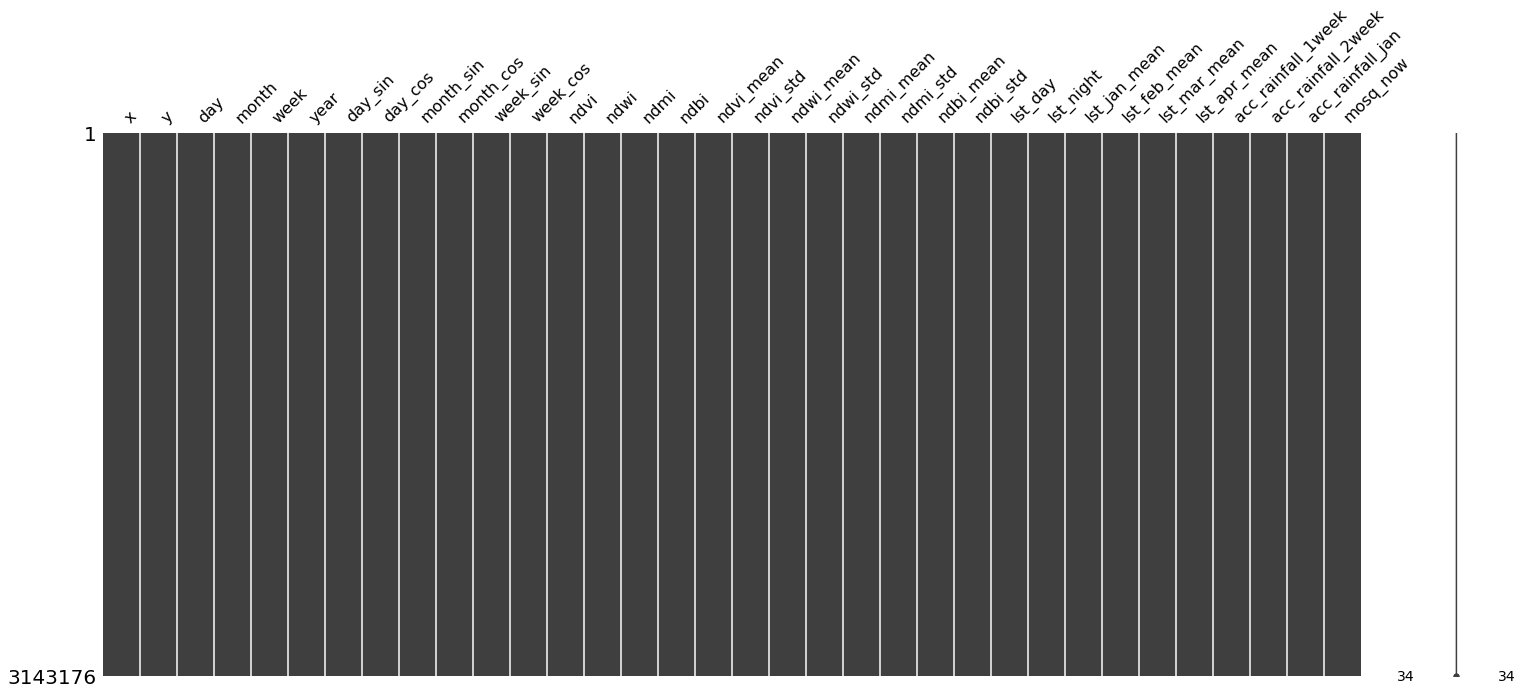

In [19]:
missingno.matrix(dataset_mamoth)

In [20]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [21]:
model_type = 'mosquito_regression'
transform_target = True

dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [22]:
predictions = give_predictions(model, dataset_mamoth)

In [23]:
mosqutio_predictions['mosq_pred'] = predictions
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,21.190130,39.661480,2010-01-01,20
1,21.190130,39.661480,2010-01-02,25
2,21.190130,39.661480,2010-01-03,25
3,21.190130,39.661480,2010-01-04,3
4,21.190130,39.661480,2010-01-05,4
...,...,...,...,...
3143171,23.299620,39.203270,2022-12-27,1
3143172,23.299620,39.203270,2022-12-28,1
3143173,23.299620,39.203270,2022-12-29,1
3143174,23.299620,39.203270,2022-12-30,1


<AxesSubplot:>

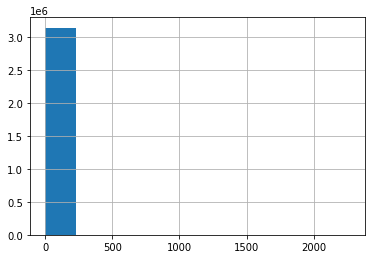

In [24]:
mosqutio_predictions.mosq_pred.hist()

In [25]:
mosqutio_predictions.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_Mosquito_Predictions_2010_2022.csv", encoding = enc, index = False)

In [26]:
dataset = pd.merge(dataset, mosqutio_predictions,  how='left', on=['x', 'y', 'dt_placement'])

In [27]:
dataset

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred
0,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190130,39.661480,2010-01-01,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.941204,NaN,NaN,NaN,NaN,NaN,40.941204,40.941204,40.941204,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,20
1,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190130,39.661480,2010-01-02,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.769920,NaN,NaN,NaN,NaN,NaN,63.711124,63.711124,63.711124,53,0.394356,0.918958,0.500000,0.866025,-0.000000,1.000000,25
2,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190130,39.661480,2010-01-03,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.007012,NaN,NaN,NaN,NaN,NaN,64.718136,64.718136,64.718136,53,0.571268,0.820763,0.500000,0.866025,-0.000000,1.000000,25
3,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190130,39.661480,2010-01-04,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.641527,NaN,NaN,NaN,NaN,NaN,68.359663,68.359663,68.359663,1,0.724793,0.688967,0.500000,0.866025,0.118273,0.992981,3
4,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190130,39.661480,2010-01-05,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.385432,NaN,NaN,NaN,NaN,NaN,69.745094,69.745094,69.745094,1,0.848644,0.528964,0.500000,0.866025,0.118273,0.992981,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3143171,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",23.299620,39.203270,2022-12-27,27,12,2022,0.437406,0.346100,-0.301129,-0.346100,0.446126,0.341544,-0.308838,-0.341544,0.023620,0.029441,0.029670,0.029441,14356.000000,14182.000000,14172.233333,14288.214286,14180.451613,14180.451613,13971.129032,13995.285714,13929.000000,13929.000000,0.000000,14269.000000,14071.681183,14141.750000,14054.725806,14054.725806,0.000000,7.205815,1157.374877,52,-0.724793,0.688967,-0.000000,1.000000,-0.118273,0.992981,1
3143172,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",23.299620,39.203270,2022-12-28,28,12,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14356.000000,14182.000000,14172.233333,14288.214286,14180.451613,14180.451613,13971.129032,13995.285714,13929.000000,13929.000000,0.000000,14269.000000,14071.681183,14141.750000,14054.725806,14054.725806,0.000000,0.000000,1157.374877,52,-0.571268,0.820763,-0.000000,1.000000,-0.118273,0.992981,1
3143173,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",23.299620,39.203270,2022-12-29,29,12,2022,0.437406,0.346100,-0.301129,-0.346100,0.446126,0.341544,-0.308838,-0.341544,0.023620,0.029441,0.029670,0.029441,14356.000000,14079.000000,14172.233333,14288.214286,14180.451613,14180.451613,13971.129032,13995.285714,13929.000000,13929.000000,0.000000,14217.500000,14071.681183,14141.750000,14054.725806,14054.725806,0.000000,0.000000,1157.374877,52,-0.394356,0.918958,-0.000000,1.000000,-0.118273,0.992981,1
3143174,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",23.299620,39.203270,2022-12-30,30,12,2022,0.437406,0.346100,-0.301129,-0.346100,0.446126,0.341544,-0.308838,-0.341544,0.023620,0.029441,0.029670,0.029441,14239.000000,14096.000000,14172.233333,14288.214286,14180.451613,14180.451613,13971.129032,13995.285714,13929.000000,13929.000000,0.000000,14167.500000,14071.681183,14141.750000,14054.725806,14054.7

In [28]:
dataset_locations = dataset[['x', 'y']].drop_duplicates(keep='first')
dataset_locations.reset_index(drop = True, inplace = True)

In [29]:
dataset_locations_per_year = dataset[['x', 'y', 'year']].drop_duplicates(keep='first')
dataset_locations_per_year.reset_index(drop = True, inplace = True)

In [30]:
dataset_locations

,x,y
0,21.190130,39.661480
1,21.236600,39.517750
2,21.236600,39.553680
3,21.236600,39.589620
4,21.236600,39.625550
...,...,...
657,23.253400,39.167330
658,23.253400,39.203270
659,23.253400,39.239200
660,23.253400,39.275130


In [31]:
dataset_locations_per_year

,x,y,year
0,21.190130,39.661480,2010
1,21.190130,39.661480,2011
2,21.190130,39.661480,2012
3,21.190130,39.661480,2013
4,21.190130,39.661480,2014
...,...,...,...
8601,23.299620,39.203270,2018
8602,23.299620,39.203270,2019
8603,23.299620,39.203270,2020
8604,23.299620,39.203270,2021


In [32]:
geomorphological = pd.read_csv(f'../../../../Greece/data/{NUTS2}/{NUTS0}_{NUTS2}_Geomorphological_filled.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [33]:
distances, indicies = calculate_nearest_topological(dataset_locations, geomorphological)
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.2232735365156893
Max distance: 14.96367055422922


In [34]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

for index in indicies:
    df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

In [35]:
dataset_geo = pd.concat([dataset_locations, df_geo], axis=1, join = 'outer')
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,21.190130,39.661480,14039.164957,1536.803194,42,68.041303,1482.920030,148.246684,0.000000,10.481867
1,21.236600,39.517750,32448.018454,621.762427,33,88.659186,1008.872950,168.779352,0.000000,1.550753
2,21.236600,39.553680,24978.643191,573.384770,25,183.182342,1298.366067,180.757700,0.000000,1.026366
3,21.236600,39.589620,24978.643191,573.384770,25,183.182342,1298.366067,180.757700,0.000000,1.026366
4,21.236600,39.625550,14039.164957,1536.803194,42,68.041303,1482.920030,148.246684,0.000000,10.481867
...,...,...,...,...,...,...,...,...,...,...
657,23.253400,39.167330,1428.272189,86.731254,21,203.135398,162.994713,169.424077,0.000000,35.001195
658,23.253400,39.203270,1428.272189,86.731254,21,203.135398,162.994713,169.424077,0.000000,35.001195
659,23.253400,39.239200,1428.272189,86.731254,21,203.135398,162.994713,169.424077,0.000000,35.001195
660,23.253400,39.275130,1428.272189,86.731254,21,203.135398,162.994713,169.424077,0.000000,35.001195


In [36]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km         object
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [37]:
dataset_geo['slope_mean_1km'] = pd.to_numeric(dataset_geo['slope_mean_1km'], errors='coerce').astype('int64')

In [38]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km          int64
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [39]:
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,21.190130,39.661480,14039.164957,1536.803194,42,68.041303,1482.920030,148.246684,0.000000,10.481867
1,21.236600,39.517750,32448.018454,621.762427,33,88.659186,1008.872950,168.779352,0.000000,1.550753
2,21.236600,39.553680,24978.643191,573.384770,25,183.182342,1298.366067,180.757700,0.000000,1.026366
3,21.236600,39.589620,24978.643191,573.384770,25,183.182342,1298.366067,180.757700,0.000000,1.026366
4,21.236600,39.625550,14039.164957,1536.803194,42,68.041303,1482.920030,148.246684,0.000000,10.481867
...,...,...,...,...,...,...,...,...,...,...
657,23.253400,39.167330,1428.272189,86.731254,21,203.135398,162.994713,169.424077,0.000000,35.001195
658,23.253400,39.203270,1428.272189,86.731254,21,203.135398,162.994713,169.424077,0.000000,35.001195
659,23.253400,39.239200,1428.272189,86.731254,21,203.135398,162.994713,169.424077,0.000000,35.001195
660,23.253400,39.275130,1428.272189,86.731254,21,203.135398,162.994713,169.424077,0.000000,35.001195


In [40]:
landcover = pd.read_csv(f'../../../../Greece/data/{NUTS2}/{NUTS0}_{NUTS2}_Landcover_2001-2021_filled.csv')
landcover.columns = landcover.columns.str.lower()

In [41]:
lc_columns = landcover.columns.tolist()
lc_columns = [x.split('_')[0] for x in lc_columns]

lc_columns
lc_years = set()

for i in range(0, len(lc_columns)):
    try:
        lc_years.add(int(lc_columns[i]))
    except ValueError:
        pass

lc_years = list(lc_years)

In [42]:
dates_ = re.compile(r"[0-9]{4}_[0-9]{2}_[0-9]{2}_")

for year in lc_years:
    frame_name = f'landcover_{year}'
    location_columns = ['x', 'y']
    filtered_columns = [col for col in landcover if col.startswith(f'{year}')]
    columns_to_keep = location_columns + filtered_columns
    locals()[frame_name] = landcover[columns_to_keep].copy()
    locals()[frame_name].insert(2, 'year', int(year))
    locals()[frame_name] = locals()[frame_name].rename(columns=lambda x: re.sub(dates_,'',x))

In [43]:
data_years = dataset_locations_per_year['year'].unique().tolist()

In [44]:
for year in data_years:
    frame_name = f'dataset_unique_points_annual_{year}'
    locals()[frame_name] = dataset_locations_per_year.query(f"year == {year}").copy()
    locals()[frame_name].reset_index(drop=True, inplace = True)

In [45]:
for year in data_years:
    data_name = f'dataset_unique_points_annual_{year}'
    lc_name = f'landcover_{year}'
    merged_name = f'dataset_unique_points_annual_part{year}'
    distances, indicies = calculate_nearest_topological(locals()[data_name], locals()[lc_name])
    print(f'Year: {year}\nMin distance: {min(distances)}\nMax distance: {max(distances)}')

    df_lulc = pd.DataFrame()

    for index in indicies:
        df_lulc = pd.concat([df_lulc, locals()[lc_name].iloc[[index]]], ignore_index=True)

    df_lulc.drop(columns=['x', 'y', 'year'], inplace = True)
    df_lulc.reset_index(drop=True, inplace=True)

    locals()[merged_name] = pd.concat([locals()[data_name], df_lulc], axis=1, join = 'outer')

Year: 2010
Min distance: 0.2232735365156893
Max distance: 14.96367055422922
Year: 2011
Min distance: 0.2232735365156893
Max distance: 14.96367055422922
Year: 2012
Min distance: 0.2232735365156893
Max distance: 14.96367055422922
Year: 2013
Min distance: 0.2232735365156893
Max distance: 14.96367055422922
Year: 2014
Min distance: 0.2232735365156893
Max distance: 14.96367055422922
Year: 2015
Min distance: 0.2232735365156893
Max distance: 14.96367055422922
Year: 2016
Min distance: 0.2232735365156893
Max distance: 14.96367055422922
Year: 2017
Min distance: 0.2232735365156893
Max distance: 14.96367055422922
Year: 2018
Min distance: 0.2232735365156893
Max distance: 14.96367055422922
Year: 2019
Min distance: 0.2232735365156893
Max distance: 14.96367055422922
Year: 2020
Min distance: 0.2232735365156893
Max distance: 14.96367055422922
Year: 2021
Min distance: 0.2232735365156893
Max distance: 14.96367055422922
Year: 2022
Min distance: 0.2232735365156893
Max distance: 14.96367055422922


In [46]:
dataset_lulc = pd.DataFrame()

for year in data_years:
    merged_name = f'dataset_unique_points_annual_part{year}'
    dataset_lulc = pd.concat([dataset_lulc, locals()[merged_name]], ignore_index=True)

In [47]:
dataset_lulc

,x,y,year,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,21.190130,39.661480,2010,31,96,36,90.000000,30,96,12,12,1,6,7,2,0
1,21.236600,39.517750,2010,15,72,10,83.000000,10,83,5,5,6,4,4,2,0
2,21.236600,39.553680,2010,15,94,10,98.000000,10,98,5,5,7,1,1,2,0
3,21.236600,39.589620,2010,15,94,10,98.000000,10,98,5,5,7,1,1,2,0
4,21.236600,39.625550,2010,31,96,36,90.000000,30,96,12,12,1,6,7,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8601,23.253400,39.167330,2022,21,73,20,73.000000,20,73,8,8,4,2,2,2,0
8602,23.253400,39.203270,2022,21,73,20,73.000000,20,73,8,8,4,2,2,2,0
8603,23.253400,39.239200,2022,21,73,20,73.000000,20,73,8,8,4,2,2,2,0
8604,23.253400,39.275130,2022,21,73,20,73.000000,20,73,8,8,4,2,2,2,0


In [48]:
dataset_lulc.dtypes

x                      float64
y                      float64
year                     int64
lc_prop1                 int64
lc_prop1_assessment      int64
lc_prop2                 int64
lc_prop2_assessment    float64
lc_prop3                 int64
lc_prop3_assessment      int64
lc_type1                 int64
lc_type2                 int64
lc_type3                 int64
lc_type4                 int64
lc_type5                 int64
lw                       int64
qc                       int64
dtype: object

In [49]:
dataset = pd.merge(dataset, dataset_geo, on=['x', 'y'], how='left')

In [50]:
dataset = pd.merge(dataset, dataset_lulc, on=['x', 'y', 'year'], how='left')

In [51]:
dataset

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190130,39.661480,2010-01-01,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.941204,NaN,NaN,NaN,NaN,NaN,40.941204,40.941204,40.941204,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,20,14039.164957,1536.803194,42,68.041303,1482.920030,148.246684,0.000000,10.481867,31,96,36,90.000000,30,96,12,12,1,6,7,2,0
1,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190130,39.661480,2010-01-02,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.769920,NaN,NaN,NaN,NaN,NaN,63.711124,63.711124,63.711124,53,0.394356,0.918958,0.500000,0.866025,-0.000000,1.000000,25,14039.164957,1536.803194,42,68.041303,1482.920030,148.246684,0.000000,10.481867,31,96,36,90.000000,30,96,12,12,1,6,7,2,0
2,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190130,39.661480,2010-01-03,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.007012,NaN,NaN,NaN,NaN,NaN,64.718136,64.718136,64.718136,53,0.571268,0.820763,0.500000,0.866025,-0.000000,1.000000,25,14039.164957,1536.803194,42,68.041303,1482.920030,148.246684,0.000000,10.481867,31,96,36,90.000000,30,96,12,12,1,6,7,2,0
3,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190130,39.661480,2010-01-04,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.641527,NaN,NaN,NaN,NaN,NaN,68.359663,68.359663,68.359663,1,0.724793,0.688967,0.500000,0.866025,0.118273,0.992981,3,14039.164957,1536.803194,42,68.041303,1482.920030,148.246684,0.000000,10.481867,31,96,36,90.000000,30,96,12,12,1,6,7,2,0
4,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190130,39.661480,2010-01-05,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.385432,NaN,NaN,NaN,NaN,NaN,69.745094,69.745094,69.745094,1,0.848644,0.528964,0.500000,0.866025,0.118273,0.992981,4,14039.164957,1536.803194,42,68.041303,1482.920030,148.246684,0.000000,10.481867,31,96,36,90.000000,30,96,12,12,1,6,7,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3143171,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",23.299620,39.203270,2022-12-27,27,12,2022,0.437406,0.346100,-0.301129,-0.346100,0.446126,0.341544,-0.308838,-0.341544,0.023620,0.029441,0.029670,0.029441,14356.000000,14182.000000,14172.233333,14288.214286,14180.451613,14180.451613,13971.129032,13995.285714,13929.000000,13929.000000,0.000000,14269.000000,14071.681183,14141.750000,14054.725806,14054.725806,0.000000,7.205815,1157.374877,52,-0.724793,0.688967,-0.000000,1.000000,-0.118273,0.992981,1,1428.272189,86.731254,21,203.135398,162.994713,169.424077,0.000000,35.001195,21,73,20,73.000000,20,73,8,8,4,2,2,2,0
3143172,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",23.299620,39.203270,2022-12-28,28,12,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14356.000000,14182.000000,14172.233333,14288.214286,14180.451613,14180.451613,13971.129032,13995.285714,13929.000000,139

In [52]:
grouped_by_nuts3 = dataset.groupby(['dt_placement', 'NUTS2_ID',	'NUTS2_NAME','NUTS3_ID','NUTS3_NAME'], as_index = False)

In [53]:
grouped_by_nuts3_mods = grouped_by_nuts3.agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None).reset_index()

In [54]:
grouped_by_nuts3_mean = grouped_by_nuts3.mean()
grouped_by_nuts3_min = grouped_by_nuts3.min()
grouped_by_nuts3_max = grouped_by_nuts3.max()
grouped_by_nuts3_std = grouped_by_nuts3.std()

In [55]:
grouped_by_nuts3_min.rename(columns={'distance_to_coast': 'distance_to_coast_min', 'distance_to_river': 'distance_to_river_min', 
                                     'slope_mean_1km': 'slope_mean_1km_min', 'aspect_mean_200m': 'aspect_mean_200m_min', 
                                     'elevation_mean_1km': 'elevation_mean_1km_min', 'hillshade_mean_1km': 'hillshade_mean_1km_min',
                                     'fs_area_1km': 'fs_area_1km_min', 'flow_accu_200m': 'flow_accu_200m_min'}, inplace=True)

grouped_by_nuts3_max.rename(columns={'distance_to_coast': 'distance_to_coast_max', 'distance_to_river': 'distance_to_river_max', 
                                     'slope_mean_1km': 'slope_mean_1km_max', 'aspect_mean_200m': 'aspect_mean_200m_max', 
                                     'elevation_mean_1km': 'elevation_mean_1km_max', 'hillshade_mean_1km': 'hillshade_mean_1km_max',
                                     'fs_area_1km': 'fs_area_1km_max', 'flow_accu_200m': 'flow_accu_200m_max'}, inplace=True)

grouped_by_nuts3_std.rename(columns={'distance_to_coast': 'distance_to_coast_std', 'distance_to_river': 'distance_to_river_std', 
                                     'slope_mean_1km': 'slope_mean_1km_std', 'aspect_mean_200m': 'aspect_mean_200m_std', 
                                     'elevation_mean_1km': 'elevation_mean_1km_std', 'hillshade_mean_1km': 'hillshade_mean_1km_std',
                                     'fs_area_1km': 'fs_area_1km_std', 'flow_accu_200m': 'flow_accu_200m_std'}, inplace=True)

In [56]:
grouped_by_nuts3_mods.drop(columns=['index'], inplace = True)

In [57]:
grouped_by_nuts3_mods

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,2010-01-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.973830,39.589620,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14497.000000,13945.000000,14497.000000,NaN,NaN,NaN,13945.000000,NaN,NaN,NaN,42.240131,14053.500000,14053.500000,NaN,NaN,NaN,42.240131,42.240131,42.240131,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,1,24978.643191,573.384770,1,183.182342,1298.366067,180.757700,0.000000,1.000000,31,94,20,98.000000,20,98,12,12,4,6,7,2,0
1,2010-01-01,EL61,θεσσαλια,EL612,λαρισα,22.303990,39.759290,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14481.000000,13758.000000,14481.000000,NaN,NaN,NaN,13758.000000,NaN,NaN,NaN,0.000441,14133.000000,14133.000000,NaN,NaN,NaN,0.000441,0.000441,0.000441,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,1,5044.978271,2049.745723,2,123.231702,66.558445,179.979366,0.000000,1.000000,31,98,36,98.000000,30,98,12,12,1,6,7,2,0
2,2010-01-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.791220,39.382930,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14416.000000,13813.000000,14416.000000,NaN,NaN,NaN,13813.000000,NaN,NaN,NaN,0.000000,14113.000000,14113.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,1,11247.348528,661.068282,5,108.316688,479.366837,151.898156,0.000000,1.000000,22,78,20,78.000000,20,78,9,9,4,1,1,2,0
3,2010-01-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.973830,39.589620,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14111.000000,13940.000000,13975.000000,NaN,NaN,NaN,13940.000000,NaN,NaN,NaN,0.000000,13943.500000,14081.750000,NaN,NaN,NaN,46.106881,46.106881,46.106881,53,0.394356,0.918958,0.500000,0.866025,-0.000000,1.000000,1,24978.643191,573.384770,1,183.182342,1298.366067,180.757700,0.000000,1.000000,31,94,20,98.000000,20,98,12,12,4,6,7,2,0
4,2010-01-02,EL61,θεσσαλια,EL612,λαρισα,22.303990,39.759290,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14481.000000,13867.000000,14481.000000,NaN,NaN,NaN,13925.000000,NaN,NaN,NaN,0.039674,14100.500000,14181.000000,NaN,NaN,NaN,0.654196,0.654196,0.654196,53,0.394356,0.918958,0.500000,0.866025,-0.000000,1.000000,1,5044.978271,2049.745723,2,123.231702,66.558445,179.979366,0.000000,1.000000,31,98,36,98.000000,30,98,12,12,1,6,7,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14239,2022-12-30,EL61,θεσσαλια,EL612,λαρισα,22.303990,39.759290,30,12,2022,0.320930,-0.212104,-0.586048,-0.526132,0.028504,-0.155496,-0.482293,-0.549401,0.000000,0.000000,0.000000,0.000000,14145.000000,13849.000000,14104.225806,14197.678571,14247.064516,14247.064516,13671.580645,13641.892857,13691.032258,13691.032258,0.000000,13955.000000,13875.161290,14009.482143,14072.548387,14072.548387,0.000000,0.000000,994.783178,52,-0.201299,0.979530,-0.000000,1.000000,-0.118273,0.992981,1,5044.978271,2049.745723,2,123.231702,66.558445,179.979366,0.000000,1.000000,31,99,36,99.000000,30,99,12,12,1,6,7,2,0
14240,2022-12-30,EL61,θεσσαλια,EL613,"μαγνησια, σποραδ

In [58]:
grouped_by_nuts3_min

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,2010-01-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190130,39.078160,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13981.000000,13683.000000,13981.000000,NaN,NaN,NaN,13683.000000,NaN,NaN,NaN,5.182834,14053.500000,14053.500000,NaN,NaN,NaN,5.182834,5.182834,5.182834,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,1,0.000000,17.263686,0,18.435249,89.042099,144.067550,0.000000,1.000000,15,66,9,66.000000,10,66,5,5,1,1,1,1,0
1,2010-01-01,EL61,θεσσαλια,EL612,λαρισα,21.979730,39.184360,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13870.000000,13476.000000,13870.000000,NaN,NaN,NaN,13476.000000,NaN,NaN,NaN,0.000000,13765.000000,13765.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,1,3052.548676,23.462650,0,58.864690,44.477528,137.763668,0.000000,1.000000,11,69,10,69.000000,10,69,1,1,1,1,1,2,0
2,2010-01-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.560130,39.023600,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14188.000000,13813.000000,14188.000000,NaN,NaN,NaN,13813.000000,NaN,NaN,NaN,0.000000,14113.000000,14113.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,1,1428.272189,86.731254,2,76.607080,25.935036,146.893807,0.000000,1.000000,11,68,10,68.000000,10,68,1,1,1,1,1,2,0
3,2010-01-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190130,39.078160,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13482.000000,13006.000000,13482.000000,NaN,NaN,NaN,13006.000000,NaN,NaN,NaN,0.000000,13755.500000,13765.000000,NaN,NaN,NaN,5.194766,5.194766,5.194766,53,0.394356,0.918958,0.500000,0.866025,-0.000000,1.000000,1,0.000000,17.263686,0,18.435249,89.042099,144.067550,0.000000,1.000000,15,66,9,66.000000,10,66,5,5,1,1,1,1,0
4,2010-01-02,EL61,θεσσαλια,EL612,λαρισα,21.979730,39.184360,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13835.000000,13476.000000,13870.000000,NaN,NaN,NaN,13487.000000,NaN,NaN,NaN,0.000000,13765.000000,13765.000000,NaN,NaN,NaN,0.012288,0.012288,0.012288,53,0.394356,0.918958,0.500000,0.866025,-0.000000,1.000000,1,3052.548676,23.462650,0,58.864690,44.477528,137.763668,0.000000,1.000000,11,69,10,69.000000,10,69,1,1,1,1,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14239,2022-12-30,EL61,θεσσαλια,EL612,λαρισα,21.979730,39.184360,30,12,2022,0.036494,-0.212104,-0.586048,-0.526132,0.028504,-0.155496,-0.482293,-0.549401,0.000000,0.000000,0.000000,0.000000,13826.000000,13503.000000,13452.612903,13607.321429,13598.419355,13598.419355,13279.000000,13360.214286,13048.935484,13048.935484,0.000000,13664.500000,13365.806452,13483.767857,13323.677419,13323.677419,-0.000000,-0.000000,738.843768,52,-0.201299,0.979530,-0.000000,1.000000,-0.118273,0.992981,1,3052.548676,23.462650,0,58.864690,44.477528,137.763668,0.000000,1.000000,11,70,10,69.000000,10,70,1,1,1,1,1,2,0
14240,2022-12-30,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.560130,

In [59]:
grouped_by_nuts3_dataset = pd.concat([grouped_by_nuts3_mods[['dt_placement','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME']], 
                                     grouped_by_nuts3_mean[['x','y']],
                                     grouped_by_nuts3_mods[['day','month','year','week']],
                                     grouped_by_nuts3_mean[['ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std']],
                                     grouped_by_nuts3_mean[['lst_day','lst_night','lst', 'rainfall','mosq_pred']],
                                     grouped_by_nuts3_mean[['distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m']],
                                     grouped_by_nuts3_min[['distance_to_coast_min','distance_to_river_min','slope_mean_1km_min','aspect_mean_200m_min','elevation_mean_1km_min','hillshade_mean_1km_min','fs_area_1km_min','flow_accu_200m_min']],
                                     grouped_by_nuts3_max[['distance_to_coast_max','distance_to_river_max','slope_mean_1km_max','aspect_mean_200m_max','elevation_mean_1km_max','hillshade_mean_1km_max','fs_area_1km_max','flow_accu_200m_max']],
                                     grouped_by_nuts3_std[['distance_to_coast_std','distance_to_river_std','slope_mean_1km_std','aspect_mean_200m_std','elevation_mean_1km_std','hillshade_mean_1km_std','fs_area_1km_std','flow_accu_200m_std']],
                                     grouped_by_nuts3_mods[['lc_prop1','lc_prop2','lc_prop3','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5','lw']]], axis=1)

In [60]:
grouped_by_nuts3_dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw
0,2010-01-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,1,1,2010,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14445.565789,13915.473684,14133.222222,39.120625,8.463668,23203.497284,1321.352593,14.861592,164.292151,614.262789,178.601039,0.031194,105.223672,0.000000,17.263686,0,18.435249,89.042099,144.067550,0.000000,1.000000,43609.055065,3375.269289,42,284.268894,1585.629960,234.678996,1.126890,1777.415878,11862.022706,952.705549,11.851873,55.244221,454.990779,15.862025,0.185197,363.881368,31,20,20,12,12,4,6,7,2
1,2010-01-01,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,1,1,2010,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14453.085185,13949.820513,14178.696581,1.096759,4.599278,20381.214080,1439.355988,8.689531,159.540756,385.364133,180.555457,0.000000,52.856210,3052.548676,23.462650,0,58.864690,44.477528,137.763668,0.000000,1.000000,43609.055065,3296.453316,34,274.218916,1298.005401,217.324430,0.000000,917.122996,10627.953220,973.394450,9.072833,54.718311,362.264034,11.708138,0.000000,155.830690,31,36,30,12,12,1,6,7,2
2,2010-01-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.869212,39.281871,1,1,2010,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14497.808511,14026.800000,14247.500000,0.071117,1.000000,7730.943948,1546.605403,13.375000,175.419649,384.028806,172.296053,0.000000,24.597040,1428.272189,86.731254,2,76.607080,25.935036,146.893807,0.000000,1.000000,24072.214417,3460.380927,32,287.978453,1222.255765,198.849501,0.000000,526.617503,5039.670458,1041.036612,8.060626,63.944266,315.422916,12.169145,0.000000,91.407642,22,20,20,9,9,4,1,1,2
3,2010-01-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,2,1,2010,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14254.989796,13887.059829,14113.905941,12.300978,12.207612,23203.497284,1321.352593,14.861592,164.292151,614.262789,178.601039,0.031194,105.223672,0.000000,17.263686,0,18.435249,89.042099,144.067550,0.000000,1.000000,43609.055065,3375.269289,42,284.268894,1585.629960,234.678996,1.126890,1777.415878,11862.022706,952.705549,11.851873,55.244221,454.990779,15.862025,0.185197,363.881368,31,20,20,12,12,4,6,7,2
4,2010-01-02,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,2,1,2010,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14423.196296,13903.841085,14162.886454,1.174605,6.671480,20381.214080,1439.355988,8.689531,159.540756,385.364133,180.555457,0.000000,52.856210,3052.548676,23.462650,0,58.864690,44.477528,137.763668,0.000000,1.000000,43609.055065,3296.453316,34,274.218916,1298.005401,217.324430,0.000000,917.122996,10627.953220,973.394450,9.072833,54.718311,362.264034,11.708138,0.000000,155.830690,31,36,30,12,12,1,6,7,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14239,2022-12-30,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,30,12,2022,52,0.322494,0.053153,-0.252553,-0.053153,0.311524,0.056624,-

<AxesSubplot:>

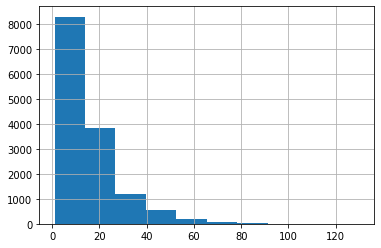

In [61]:
grouped_by_nuts3_dataset.mosq_pred.hist()

In [62]:
grouped_by_nuts3_dataset = convert_temperature(grouped_by_nuts3_dataset)

<AxesSubplot:>

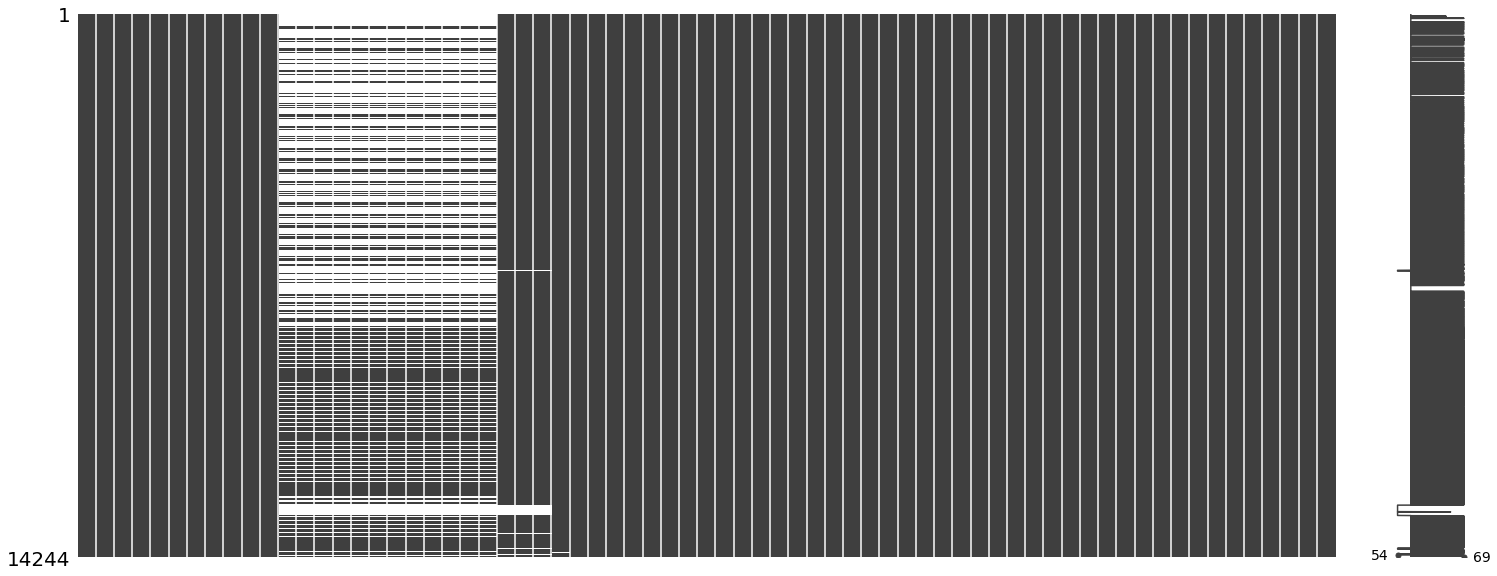

In [63]:
missingno.matrix(grouped_by_nuts3_dataset)

### Add Bio Variables ###

In [64]:
bio_values = []

for region in grouped_by_nuts3_dataset.NUTS3_NAME.unique():
    for year in grouped_by_nuts3_dataset.year.unique():
        for month in grouped_by_nuts3_dataset.month.unique():
            filtered_df = grouped_by_nuts3_dataset.loc[(grouped_by_nuts3_dataset['year'] == year) & (grouped_by_nuts3_dataset['NUTS3_NAME'] == region) & (grouped_by_nuts3_dataset['month'] == month)].copy()
            tmin = min(filtered_df['lst_day'].min(), filtered_df['lst_night'].min())
            tmax = max(filtered_df['lst_day'].max(), filtered_df['lst_night'].max())
            prec = filtered_df['rainfall'].sum()
            bio_values.append({'NUTS3_NAME': region, 
                               'year': year, 
                               'month': month, 
                               'monthly_lst_min': tmin, 
                               'monthly_lst_max': tmax,
                               'monthly_acc_prec': prec})

In [65]:
bio_values_df = pd.DataFrame(bio_values)

In [66]:
bio_values_df

,NUTS3_NAME,year,month,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,"καρδιτσα, τρικαλα",2010,1,-0.969514,15.761316,207.415431
1,"καρδιτσα, τρικαλα",2010,2,-3.042901,13.286678,310.442081
2,"καρδιτσα, τρικαλα",2010,3,-0.464256,20.833599,156.011730
3,"καρδιτσα, τρικαλα",2010,4,4.727924,25.661142,63.515774
4,"καρδιτσα, τρικαλα",2010,5,9.485156,31.632076,127.189419
...,...,...,...,...,...,...
463,"μαγνησια, σποραδες",2022,8,19.565208,37.241875,130.514889
464,"μαγνησια, σποραδες",2022,9,10.667917,32.582292,80.552314
465,"μαγνησια, σποραδες",2022,10,10.061875,29.677708,13.090772
466,"μαγνησια, σποραδες",2022,11,5.671458,24.741042,58.536737


In [67]:
dataset = pd.merge(grouped_by_nuts3_dataset, bio_values_df, on=['NUTS3_NAME', 'year', 'month'], how='left')

In [68]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2010-01-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,1,1,2010,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.761316,5.159474,10.460395,39.120625,8.463668,23203.497284,1321.352593,14.861592,164.292151,614.262789,178.601039,0.031194,105.223672,0.000000,17.263686,0,18.435249,89.042099,144.067550,0.000000,1.000000,43609.055065,3375.269289,42,284.268894,1585.629960,234.678996,1.126890,1777.415878,11862.022706,952.705549,11.851873,55.244221,454.990779,15.862025,0.185197,363.881368,31,20,20,12,12,4,6,7,2,-0.969514,15.761316,207.415431
1,2010-01-01,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,1,1,2010,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.911704,5.846410,10.879057,1.096759,4.599278,20381.214080,1439.355988,8.689531,159.540756,385.364133,180.555457,0.000000,52.856210,3052.548676,23.462650,0,58.864690,44.477528,137.763668,0.000000,1.000000,43609.055065,3296.453316,34,274.218916,1298.005401,217.324430,0.000000,917.122996,10627.953220,973.394450,9.072833,54.718311,362.264034,11.708138,0.000000,155.830690,31,36,30,12,12,1,6,7,2,-0.715704,15.911704,93.733414
2,2010-01-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.869212,39.281871,1,1,2010,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.806170,7.386000,12.096085,0.071117,1.000000,7730.943948,1546.605403,13.375000,175.419649,384.028806,172.296053,0.000000,24.597040,1428.272189,86.731254,2,76.607080,25.935036,146.893807,0.000000,1.000000,24072.214417,3460.380927,32,287.978453,1222.255765,198.849501,0.000000,526.617503,5039.670458,1041.036612,8.060626,63.944266,315.422916,12.169145,0.000000,91.407642,22,20,20,9,9,4,1,1,2,0.040625,16.806170,150.488717
3,2010-01-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,2,1,2010,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.949796,4.591197,8.270496,12.300978,12.207612,23203.497284,1321.352593,14.861592,164.292151,614.262789,178.601039,0.031194,105.223672,0.000000,17.263686,0,18.435249,89.042099,144.067550,0.000000,1.000000,43609.055065,3375.269289,42,284.268894,1585.629960,234.678996,1.126890,1777.415878,11862.022706,952.705549,11.851873,55.244221,454.990779,15.862025,0.185197,363.881368,31,20,20,12,12,4,6,7,2,-0.969514,15.761316,207.415431
4,2010-01-02,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,2,1,2010,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.313926,4.926822,10.120374,1.174605,6.671480,20381.214080,1439.355988,8.689531,159.540756,385.364133,180.555457,0.000000,52.856210,3052.548676,23.462650,0,58.864690,44.477528,137.763668,0.000000,1.000000,43609.055065,3296.453316,34,274.218916,1298.005401,217.324430,0.000000,917.122996,10627.953220,973.394450,9.072833,54.718311,362.264034,11.708138,0.000000,155.830690,31,36,30,12,12,1,6,7,2,-0.715704,15.911704,93.733414
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

<AxesSubplot:>

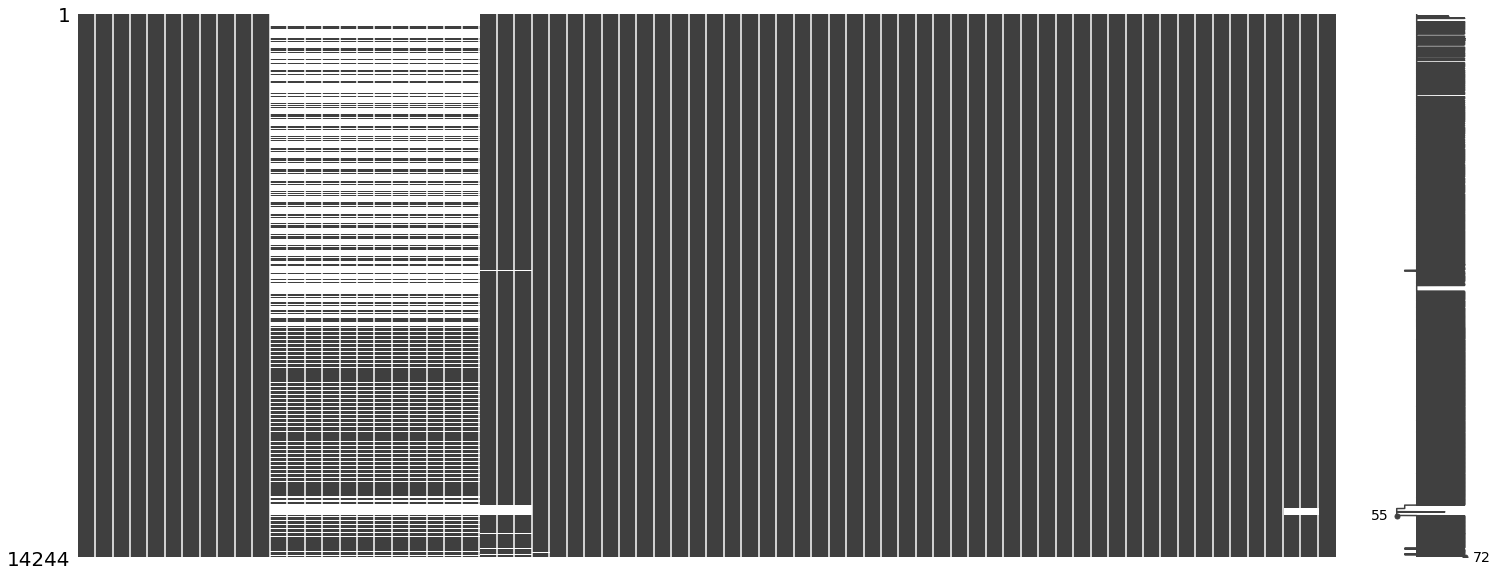

In [69]:
missingno.matrix(dataset)

In [70]:
dataset.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)

In [71]:
dataset['date_string'] = dataset['month'].astype(str) + '-' + dataset['year'].astype(str)
dataset['dt_placement'] = pd.to_datetime(dataset['date_string'], format='%m-%Y').dt.to_period('M')
dataset.drop(columns=['date_string'], inplace = True)

In [72]:
dataset

,dt_placement_daily,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,dt_placement
0,2010-01-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,1,1,2010,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.761316,5.159474,10.460395,39.120625,8.463668,23203.497284,1321.352593,14.861592,164.292151,614.262789,178.601039,0.031194,105.223672,0.000000,17.263686,0,18.435249,89.042099,144.067550,0.000000,1.000000,43609.055065,3375.269289,42,284.268894,1585.629960,234.678996,1.126890,1777.415878,11862.022706,952.705549,11.851873,55.244221,454.990779,15.862025,0.185197,363.881368,31,20,20,12,12,4,6,7,2,-0.969514,15.761316,207.415431,2010-01
1,2010-01-01,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,1,1,2010,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.911704,5.846410,10.879057,1.096759,4.599278,20381.214080,1439.355988,8.689531,159.540756,385.364133,180.555457,0.000000,52.856210,3052.548676,23.462650,0,58.864690,44.477528,137.763668,0.000000,1.000000,43609.055065,3296.453316,34,274.218916,1298.005401,217.324430,0.000000,917.122996,10627.953220,973.394450,9.072833,54.718311,362.264034,11.708138,0.000000,155.830690,31,36,30,12,12,1,6,7,2,-0.715704,15.911704,93.733414,2010-01
2,2010-01-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.869212,39.281871,1,1,2010,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.806170,7.386000,12.096085,0.071117,1.000000,7730.943948,1546.605403,13.375000,175.419649,384.028806,172.296053,0.000000,24.597040,1428.272189,86.731254,2,76.607080,25.935036,146.893807,0.000000,1.000000,24072.214417,3460.380927,32,287.978453,1222.255765,198.849501,0.000000,526.617503,5039.670458,1041.036612,8.060626,63.944266,315.422916,12.169145,0.000000,91.407642,22,20,20,9,9,4,1,1,2,0.040625,16.806170,150.488717,2010-01
3,2010-01-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,2,1,2010,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.949796,4.591197,8.270496,12.300978,12.207612,23203.497284,1321.352593,14.861592,164.292151,614.262789,178.601039,0.031194,105.223672,0.000000,17.263686,0,18.435249,89.042099,144.067550,0.000000,1.000000,43609.055065,3375.269289,42,284.268894,1585.629960,234.678996,1.126890,1777.415878,11862.022706,952.705549,11.851873,55.244221,454.990779,15.862025,0.185197,363.881368,31,20,20,12,12,4,6,7,2,-0.969514,15.761316,207.415431,2010-01
4,2010-01-02,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,2,1,2010,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.313926,4.926822,10.120374,1.174605,6.671480,20381.214080,1439.355988,8.689531,159.540756,385.364133,180.555457,0.000000,52.856210,3052.548676,23.462650,0,58.864690,44.477528,137.763668,0.000000,1.000000,43609.055065,3296.453316,34,274.218916,1298.005401,217.324430,0.000000,917.122996,10627.953220,973.394450,9.072833,54.718311,362.264034,11.708138,0.000000,155.830690,31,36,30,12,12,1,6,7,2,-0.715704,15.911704,93.733414,2010-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

In [73]:
grouped_by_month = dataset.drop(columns=['dt_placement_daily']).groupby(['dt_placement', 'NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME'], as_index = False)

grouped_by_month_mods = grouped_by_month.agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None).reset_index()
grouped_by_month_mean = grouped_by_month.mean()
grouped_by_month_min = grouped_by_month.min()
grouped_by_month_max = grouped_by_month.max()
grouped_by_month_sum = grouped_by_month.sum()

grouped_by_month_mods

,index,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,0,2010-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,1,1,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.141847,2.063333,4.160780,0.010662,1.515571,23203.497284,1321.352593,14.861592,164.292151,614.262789,178.601039,0.031194,105.223672,0.000000,17.263686,0,18.435249,89.042099,144.067550,0.000000,1.000000,43609.055065,3375.269289,42,284.268894,1585.629960,234.678996,1.126890,1777.415878,11862.022706,952.705549,11.851873,55.244221,454.990779,15.862025,0.185197,363.881368,31,20,20,12,12,4,6,7,2,-0.969514,15.761316,207.415431
1,1,2010-01,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,1,1,2010,1,NaN,NaN,NaN,NaN,-0.000415,0.447462,0.591233,-0.447462,0.000366,0.008830,0.005321,0.008830,10.799747,-0.510722,2.808412,0.002883,1.075812,20381.214080,1439.355988,8.689531,159.540756,385.364133,180.555457,0.000000,52.856210,3052.548676,23.462650,0,58.864690,44.477528,137.763668,0.000000,1.000000,43609.055065,3296.453316,34,274.218916,1298.005401,217.324430,0.000000,917.122996,10627.953220,973.394450,9.072833,54.718311,362.264034,11.708138,0.000000,155.830690,31,36,30,12,12,1,6,7,2,-0.715704,15.911704,93.733414
2,2,2010-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.869212,39.281871,1,1,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.802917,0.358750,3.498229,0.032186,1.000000,7730.943948,1546.605403,13.375000,175.419649,384.028806,172.296053,0.000000,24.597040,1428.272189,86.731254,2,76.607080,25.935036,146.893807,0.000000,1.000000,24072.214417,3460.380927,32,287.978453,1222.255765,198.849501,0.000000,526.617503,5039.670458,1041.036612,8.060626,63.944266,315.422916,12.169145,0.000000,91.407642,22,20,20,9,9,4,1,1,2,0.040625,16.806170,150.488717
3,3,2010-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,1,2,2010,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.802180,0.532319,3.485363,0.000192,6.633218,23203.497284,1321.352593,14.861592,164.292151,614.262789,178.601039,0.031194,105.223672,0.000000,17.263686,0,18.435249,89.042099,144.067550,0.000000,1.000000,43609.055065,3375.269289,42,284.268894,1585.629960,234.678996,1.126890,1777.415878,11862.022706,952.705549,11.851873,55.244221,454.990779,15.862025,0.185197,363.881368,31,20,20,12,12,4,6,7,2,-3.042901,13.286678,310.442081
4,4,2010-02,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,1,2,2010,5,0.321330,0.350577,0.083743,-0.350577,0.317564,0.333333,0.063260,-0.333333,0.041787,0.055516,0.075366,0.055516,10.752094,-0.669708,5.041193,0.024860,5.465704,20381.214080,1439.355988,8.689531,159.540756,385.364133,180.555457,0.000000,52.856210,3052.548676,23.462650,0,58.864690,44.477528,137.763668,0.000000,1.000000,43609.055065,3296.453316,34,274.218916,1298.005401,217.324430,0.000000,917.122996,10627.953220,973.394450,9.072833,54.718311,362.264034,11.708138,0.000000,155.830690,31,36,30,12,12,1,6,7,2,-2.894380,15.076065,206.651624
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

In [74]:
grouped_by_month_dataset = pd.concat([grouped_by_month_mods[['dt_placement','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME']], 
                                     grouped_by_month_mean[['x','y']],
                                     grouped_by_month_mods[['month','year']],
                                     grouped_by_month_mean[['ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std','lst_day','lst_night','lst','rainfall']],
                                     grouped_by_month_sum[['mosq_pred']],
                                     grouped_by_month_mods[['distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m']],
                                     grouped_by_month_mods[['distance_to_coast_min','distance_to_river_min','slope_mean_1km_min','aspect_mean_200m_min','elevation_mean_1km_min','hillshade_mean_1km_min','fs_area_1km_min','flow_accu_200m_min']],
                                     grouped_by_month_mods[['distance_to_coast_max','distance_to_river_max','slope_mean_1km_max','aspect_mean_200m_max','elevation_mean_1km_max','hillshade_mean_1km_max','fs_area_1km_max','flow_accu_200m_max']],
                                     grouped_by_month_mods[['distance_to_coast_std','distance_to_river_std','slope_mean_1km_std','aspect_mean_200m_std','elevation_mean_1km_std','hillshade_mean_1km_std','fs_area_1km_std','flow_accu_200m_std']],
                                     grouped_by_month_mods[['lc_prop1','lc_prop2','lc_prop3','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5','lw']],
                                     grouped_by_month_mods[['monthly_lst_min','monthly_lst_max','monthly_acc_prec']]], axis=1)

In [75]:
grouped_by_month_dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2010-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.195364,1.570202,3.882783,6.690820,98.865052,23203.497284,1321.352593,14.861592,164.292151,614.262789,178.601039,0.031194,105.223672,0.000000,17.263686,0,18.435249,89.042099,144.067550,0.000000,1.000000,43609.055065,3375.269289,42,284.268894,1585.629960,234.678996,1.126890,1777.415878,11862.022706,952.705549,11.851873,55.244221,454.990779,15.862025,0.185197,363.881368,31,20,20,12,12,4,6,7,2,-0.969514,15.761316,207.415431
1,2010-01,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,1,2010,NaN,NaN,NaN,NaN,-0.000415,0.447462,0.591233,-0.447462,0.000366,0.008830,0.005321,0.008830,10.141210,1.954030,6.047620,3.023659,68.808664,20381.214080,1439.355988,8.689531,159.540756,385.364133,180.555457,0.000000,52.856210,3052.548676,23.462650,0,58.864690,44.477528,137.763668,0.000000,1.000000,43609.055065,3296.453316,34,274.218916,1298.005401,217.324430,0.000000,917.122996,10627.953220,973.394450,9.072833,54.718311,362.264034,11.708138,0.000000,155.830690,31,36,30,12,12,1,6,7,2,-0.715704,15.911704,93.733414
2,2010-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.869212,39.281871,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.030960,3.318312,6.674636,4.854475,31.010417,7730.943948,1546.605403,13.375000,175.419649,384.028806,172.296053,0.000000,24.597040,1428.272189,86.731254,2,76.607080,25.935036,146.893807,0.000000,1.000000,24072.214417,3460.380927,32,287.978453,1222.255765,198.849501,0.000000,526.617503,5039.670458,1041.036612,8.060626,63.944266,315.422916,12.169145,0.000000,91.407642,22,20,20,9,9,4,1,1,2,0.040625,16.806170,150.488717
3,2010-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,2,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.839973,1.268766,4.554370,11.087217,445.038062,23203.497284,1321.352593,14.861592,164.292151,614.262789,178.601039,0.031194,105.223672,0.000000,17.263686,0,18.435249,89.042099,144.067550,0.000000,1.000000,43609.055065,3375.269289,42,284.268894,1585.629960,234.678996,1.126890,1777.415878,11862.022706,952.705549,11.851873,55.244221,454.990779,15.862025,0.185197,363.881368,31,20,20,12,12,4,6,7,2,-3.042901,13.286678,310.442081
4,2010-02,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,2,2010,0.321330,0.350577,0.083743,-0.350577,0.317564,0.333333,0.063260,-0.333333,0.041787,0.055516,0.075366,0.055516,11.048597,2.689361,6.868979,7.380415,285.415162,20381.214080,1439.355988,8.689531,159.540756,385.364133,180.555457,0.000000,52.856210,3052.548676,23.462650,0,58.864690,44.477528,137.763668,0.000000,1.000000,43609.055065,3296.453316,34,274.218916,1298.005401,217.324430,0.000000,917.122996,10627.953220,973.394450,9.072833,54.718311,362.264034,11.708138,0.000000,155.830690,31,36,30,12,12,1,6,7,2,-2.894380,15.076065,206.651624
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

In [76]:
wnv_file.head(5)

,NUTS2_NAME,NUTS3_NAME,dt_placement,cases
0,θεσσαλια,"καρδιτσα, τρικαλα",2010-07,0
1,θεσσαλια,"καρδιτσα, τρικαλα",2010-08,0
2,θεσσαλια,"καρδιτσα, τρικαλα",2010-09,0
3,θεσσαλια,"καρδιτσα, τρικαλα",2010-10,0
4,θεσσαλια,"καρδιτσα, τρικαλα",2011-07,3


In [77]:
grouped_by_month_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 468 entries, 0 to 467
Data columns (total 70 columns):
 #   Column                  Non-Null Count  Dtype    
---  ------                  --------------  -----    
 0   dt_placement            468 non-null    period[M]
 1   NUTS2_ID                468 non-null    object   
 2   NUTS2_NAME              468 non-null    object   
 3   NUTS3_ID                468 non-null    object   
 4   NUTS3_NAME              468 non-null    object   
 5   x                       468 non-null    float64  
 6   y                       468 non-null    float64  
 7   month                   468 non-null    int64    
 8   year                    468 non-null    int64    
 9   ndvi                    458 non-null    float64  
 10  ndmi                    458 non-null    float64  
 11  ndwi                    458 non-null    float64  
 12  ndbi                    458 non-null    float64  
 13  ndvi_mean               460 non-null    float64  
 14  ndmi_mean 

In [78]:
wnv_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   NUTS2_NAME    72 non-null     object
 1   NUTS3_NAME    72 non-null     object
 2   dt_placement  72 non-null     object
 3   cases         72 non-null     int64 
dtypes: int64(1), object(3)
memory usage: 2.4+ KB


In [79]:
wnv_file['dt_placement'] = pd.to_datetime(wnv_file['dt_placement'], format='%Y-%m').dt.to_period('M')

In [80]:
wnv_file

,NUTS2_NAME,NUTS3_NAME,dt_placement,cases
0,θεσσαλια,"καρδιτσα, τρικαλα",2010-07,0
1,θεσσαλια,"καρδιτσα, τρικαλα",2010-08,0
2,θεσσαλια,"καρδιτσα, τρικαλα",2010-09,0
3,θεσσαλια,"καρδιτσα, τρικαλα",2010-10,0
4,θεσσαλια,"καρδιτσα, τρικαλα",2011-07,3
5,θεσσαλια,"καρδιτσα, τρικαλα",2011-08,8
6,θεσσαλια,"καρδιτσα, τρικαλα",2011-09,3
7,θεσσαλια,"καρδιτσα, τρικαλα",2011-10,0
8,θεσσαλια,"καρδιτσα, τρικαλα",2018-07,0
9,θεσσαλια,"καρδιτσα, τρικαλα",2018-08,0


In [81]:
wnv_file['cases'].value_counts()

0     43
1      6
2      5
3      4
4      3
8      2
5      2
7      2
6      2
15     1
19     1
23     1
Name: cases, dtype: int64

In [82]:
wnv_file.cases.sum()

149

In [83]:
merged = grouped_by_month_dataset.merge(wnv_file, how='left', on=['dt_placement', 'NUTS3_NAME', 'NUTS2_NAME'] )

In [84]:
merged

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases
0,2010-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.195364,1.570202,3.882783,6.690820,98.865052,23203.497284,1321.352593,14.861592,164.292151,614.262789,178.601039,0.031194,105.223672,0.000000,17.263686,0,18.435249,89.042099,144.067550,0.000000,1.000000,43609.055065,3375.269289,42,284.268894,1585.629960,234.678996,1.126890,1777.415878,11862.022706,952.705549,11.851873,55.244221,454.990779,15.862025,0.185197,363.881368,31,20,20,12,12,4,6,7,2,-0.969514,15.761316,207.415431,NaN
1,2010-01,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,1,2010,NaN,NaN,NaN,NaN,-0.000415,0.447462,0.591233,-0.447462,0.000366,0.008830,0.005321,0.008830,10.141210,1.954030,6.047620,3.023659,68.808664,20381.214080,1439.355988,8.689531,159.540756,385.364133,180.555457,0.000000,52.856210,3052.548676,23.462650,0,58.864690,44.477528,137.763668,0.000000,1.000000,43609.055065,3296.453316,34,274.218916,1298.005401,217.324430,0.000000,917.122996,10627.953220,973.394450,9.072833,54.718311,362.264034,11.708138,0.000000,155.830690,31,36,30,12,12,1,6,7,2,-0.715704,15.911704,93.733414,NaN
2,2010-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.869212,39.281871,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.030960,3.318312,6.674636,4.854475,31.010417,7730.943948,1546.605403,13.375000,175.419649,384.028806,172.296053,0.000000,24.597040,1428.272189,86.731254,2,76.607080,25.935036,146.893807,0.000000,1.000000,24072.214417,3460.380927,32,287.978453,1222.255765,198.849501,0.000000,526.617503,5039.670458,1041.036612,8.060626,63.944266,315.422916,12.169145,0.000000,91.407642,22,20,20,9,9,4,1,1,2,0.040625,16.806170,150.488717,NaN
3,2010-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,2,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.839973,1.268766,4.554370,11.087217,445.038062,23203.497284,1321.352593,14.861592,164.292151,614.262789,178.601039,0.031194,105.223672,0.000000,17.263686,0,18.435249,89.042099,144.067550,0.000000,1.000000,43609.055065,3375.269289,42,284.268894,1585.629960,234.678996,1.126890,1777.415878,11862.022706,952.705549,11.851873,55.244221,454.990779,15.862025,0.185197,363.881368,31,20,20,12,12,4,6,7,2,-3.042901,13.286678,310.442081,NaN
4,2010-02,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,2,2010,0.321330,0.350577,0.083743,-0.350577,0.317564,0.333333,0.063260,-0.333333,0.041787,0.055516,0.075366,0.055516,11.048597,2.689361,6.868979,7.380415,285.415162,20381.214080,1439.355988,8.689531,159.540756,385.364133,180.555457,0.000000,52.856210,3052.548676,23.462650,0,58.864690,44.477528,137.763668,0.000000,1.000000,43609.055065,3296.453316,34,274.218916,1298.005401,217.324430,0.000000,917.122996,10627.953220,973.394450,9.072833,54.718311,362.264034,11.708138,0.000000,155.830690,31,36,30,12,12,1,6,7,2,-2.894380,15.076065,206.651624,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

In [85]:
merged = fillna(merged,{'cases': 0})

In [86]:
merged['cases'].value_counts()

0.000000     439
1.000000       6
2.000000       5
3.000000       4
4.000000       3
5.000000       2
8.000000       2
7.000000       2
6.000000       2
15.000000      1
19.000000      1
23.000000      1
Name: cases, dtype: int64

In [87]:
merged.cases.sum()

149.0

In [88]:
merged = merged.astype({'cases': 'int'})

<AxesSubplot:>

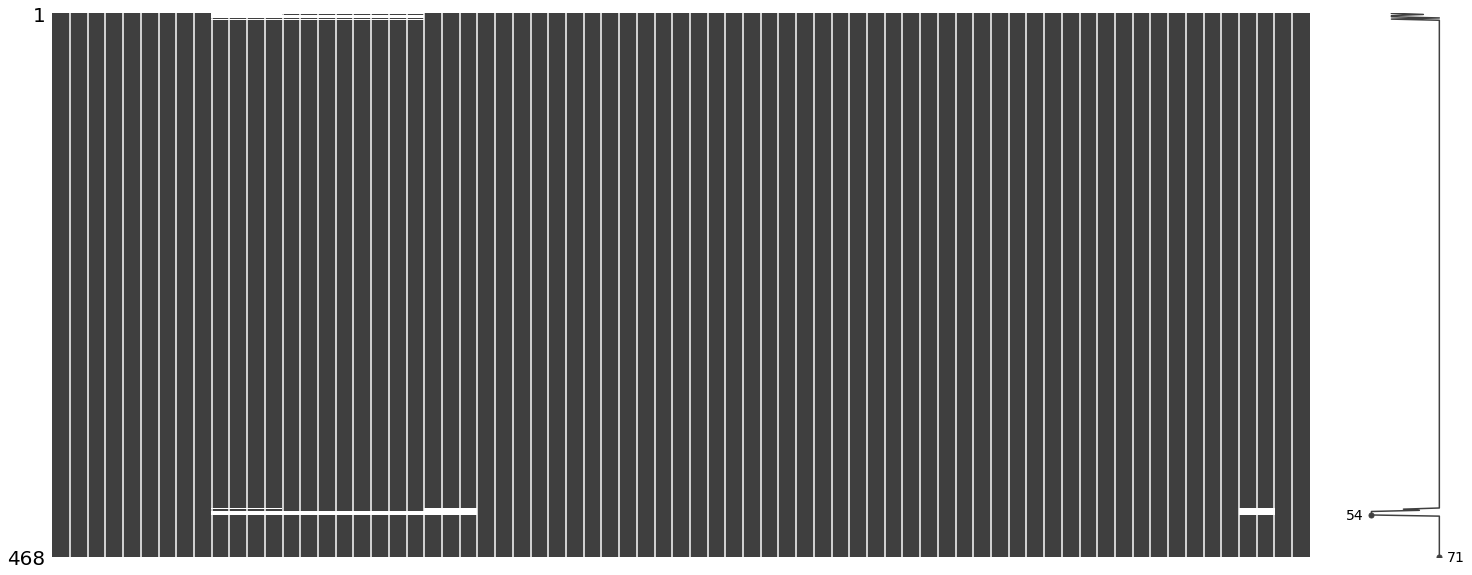

In [89]:
missingno.matrix(merged)

In [90]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'month', 'year', 'monthly_lst_min', 'monthly_lst_max']

temp_df = merged[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['monthly_lst_min', 'monthly_lst_max']

merged[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

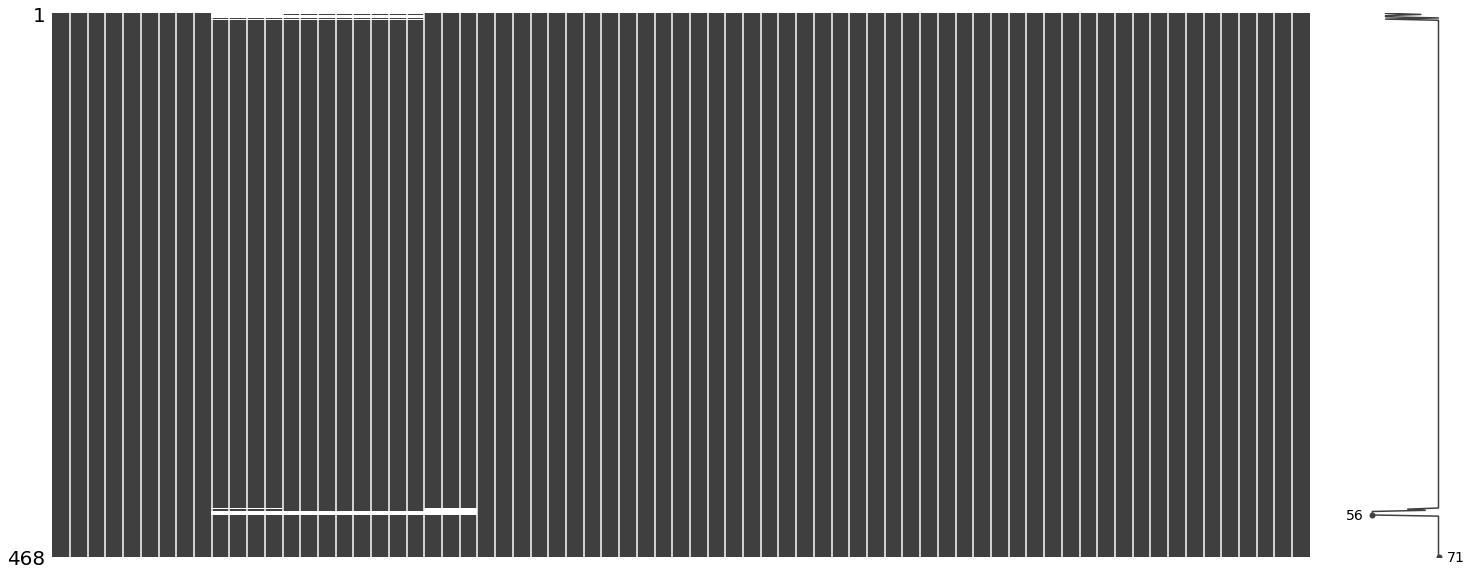

In [91]:
missingno.matrix(merged)

In [92]:
years = merged.year.unique()
years

array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
       2021, 2022], dtype=int64)

In [93]:
nuts3_units = merged.NUTS3_NAME.unique()
nuts3_units

array(['καρδιτσα, τρικαλα', 'λαρισα', 'μαγνησια, σποραδες'], dtype=object)

In [94]:
rows = []
for year in years:
    for region in nuts3_units:
        filtered_df = merged.loc[(merged['year'] == year) & (merged['NUTS3_NAME'] == region)].copy()
        filtered_df.reset_index(drop = True, inplace = True)

        tmin = robjects.IntVector(filtered_df['monthly_lst_min'].tolist())
        tmax = robjects.IntVector(filtered_df['monthly_lst_max'].tolist())
        prec = robjects.IntVector(filtered_df['monthly_acc_prec'].tolist())

        bio_vars = list(dismo.biovars(prec, tmin, tmax))

        rows.append({'NUTS3_NAME': region, 
                     'year': year, 
                     'bio1': bio_vars[0],
                     'bio2': bio_vars[1],
                     'bio3': bio_vars[2],
                     'bio4': bio_vars[3],
                     'bio5': bio_vars[4],
                     'bio6': bio_vars[5],
                     'bio7': bio_vars[6],
                     'bio8': bio_vars[7],
                     'bio9': bio_vars[8],
                     'bio10': bio_vars[9],
                     'bio11': bio_vars[10],
                     'bio12': bio_vars[11],
                     'bio13': bio_vars[12],
                     'bio14': bio_vars[13],
                     'bio15': bio_vars[14],
                     'bio16': bio_vars[15],
                     'bio17': bio_vars[16],
                     'bio18': bio_vars[17],
                     'bio19': bio_vars[18]})
        
biovars_df = pd.DataFrame(rows)

In [95]:
biovars_df.head(20)

,NUTS3_NAME,year,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,"καρδιτσα, τρικαλα",2010,15.333333,19.166667,46.747967,795.536792,38.000000,-3.000000,41.000000,15.000000,25.500000,25.500000,6.000000,2002.000000,348.000000,9.000000,63.000736,812.000000,142.000000,142.000000,702.000000
1,λαρισα,2010,17.291667,21.583333,47.962963,881.233210,42.000000,-3.000000,45.000000,17.166667,28.333333,28.333333,6.666667,1371.000000,275.000000,22.000000,62.577013,550.000000,158.000000,158.000000,378.000000
2,"μαγνησια, σποραδες",2010,17.333333,19.000000,46.341463,808.571505,40.000000,-1.000000,41.000000,17.000000,27.666667,27.666667,7.833333,1243.000000,266.000000,10.000000,67.794059,476.000000,129.000000,129.000000,391.000000
3,"καρδιτσα, τρικαλα",2011,13.958333,19.250000,49.358974,841.929152,35.000000,-4.000000,39.000000,3.833333,24.333333,24.333333,3.833333,1223.000000,212.000000,2.000000,63.539911,472.000000,91.000000,91.000000,472.000000
4,λαρισα,2011,15.916667,22.500000,48.913043,906.249347,42.000000,-4.000000,46.000000,10.166667,27.333333,27.333333,5.666667,928.000000,123.000000,4.000000,50.136650,314.000000,136.000000,136.000000,284.000000
5,"μαγνησια, σποραδες",2011,15.583333,18.666667,47.863248,831.163843,37.000000,-2.000000,39.000000,7.166667,26.000000,26.000000,6.166667,1083.000000,180.000000,1.000000,59.487453,449.000000,124.000000,124.000000,381.000000
6,"καρδιτσα, τρικαλα",2012,15.458333,20.750000,43.229167,940.130149,40.000000,-8.000000,48.000000,11.333333,26.333333,26.333333,3.333333,1786.000000,341.000000,9.000000,69.864508,797.000000,51.000000,51.000000,677.000000
7,λαρισα,2012,17.750000,24.000000,46.153846,944.722181,45.000000,-7.000000,52.000000,13.666667,28.833333,28.833333,5.666667,1276.000000,185.000000,7.000000,65.541262,502.000000,54.000000,54.000000,422.000000
8,"μαγνησια, σποραδες",2012,17.291667,20.416667,44.384058,892.763415,41.000000,-5.000000,46.000000,6.000000,28.000000,28.000000,6.000000,1254.000000,206.000000,1.000000,68.589663,485.000000,30.000000,30.000000,485.000000
9,"καρδιτσα, τρικαλα",2013,15.666667,19.000000,44.186047,888.648958,38.000000,-5.000000,43.000000,5.666667,25.666667,25.666667,4.000000,1633.000000,297.000000,5.000000,74.105304,732.000000,126.000000,126.000000,724.000000


In [96]:
merged = pd.merge(merged, biovars_df,  how='left', on=['NUTS3_NAME', 'year'])

In [98]:
##check if biovars have the same value across all months
merged.loc[(merged['year'] == 2010) & (merged['NUTS3_NAME'] == 'λαρισα')]

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
1,2010-01,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,1,2010,NaN,NaN,NaN,NaN,-0.000415,0.447462,0.591233,-0.447462,0.000366,0.008830,0.005321,0.008830,10.141210,1.954030,6.047620,3.023659,68.808664,20381.214080,1439.355988,8.689531,159.540756,385.364133,180.555457,0.000000,52.856210,3052.548676,23.462650,0,58.864690,44.477528,137.763668,0.000000,1.000000,43609.055065,3296.453316,34,274.218916,1298.005401,217.324430,0.000000,917.122996,10627.953220,973.394450,9.072833,54.718311,362.264034,11.708138,0.000000,155.830690,31,36,30,12,12,1,6,7,2,-0.715704,15.911704,93.733414,0,17.291667,21.583333,47.962963,881.233210,42.000000,-3.000000,45.000000,17.166667,28.333333,28.333333,6.666667,1371.000000,275.000000,22.000000,62.577013,550.000000,158.000000,158.000000,378.000000
4,2010-02,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,2,2010,0.321330,0.350577,0.083743,-0.350577,0.317564,0.333333,0.063260,-0.333333,0.041787,0.055516,0.075366,0.055516,11.048597,2.689361,6.868979,7.380415,285.415162,20381.214080,1439.355988,8.689531,159.540756,385.364133,180.555457,0.000000,52.856210,3052.548676,23.462650,0,58.864690,44.477528,137.763668,0.000000,1.000000,43609.055065,3296.453316,34,274.218916,1298.005401,217.324430,0.000000,917.122996,10627.953220,973.394450,9.072833,54.718311,362.264034,11.708138,0.000000,155.830690,31,36,30,12,12,1,6,7,2,-2.894380,15.076065,206.651624,0,17.291667,21.583333,47.962963,881.233210,42.000000,-3.000000,45.000000,17.166667,28.333333,28.333333,6.666667,1371.000000,275.000000,22.000000,62.577013,550.000000,158.000000,158.000000,378.000000
7,2010-03,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,3,2010,0.441410,0.198303,-0.215007,-0.198303,0.441695,0.194832,-0.220573,-0.194832,0.063358,0.073918,0.050419,0.073918,18.168460,5.027112,11.597786,3.843650,310.263538,20381.214080,1439.355988,8.689531,159.540756,385.364133,180.555457,0.000000,52.856210,3052.548676,23.462650,0,58.864690,44.477528,137.763668,0.000000,1.000000,43609.055065,3296.453316,34,274.218916,1298.005401,217.324430,0.000000,917.122996,10627.953220,973.394450,9.072833,54.718311,362.264034,11.708138,0.000000,155.830690,31,36,30,12,12,1,6,7,2,1.375848,23.163574,119.153165,0,17.291667,21.583333,47.962963,881.233210,42.000000,-3.000000,45.000000,17.166667,28.333333,28.333333,6.666667,1371.000000,275.000000,22.000000,62.577013,550.000000,158.000000,158.000000,378.000000
10,2010-04,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,4,2010,0.469497,0.169357,-0.280994,-0.169357,0.469086,0.177772,-0.270364,-0.177772,0.057781,0.066050,0.037286,0.066050,22.407853,7.948505,15.178179,1.617025,267.552347,20381.214080,1439.355988,8.689531,159.540756,385.364133,180.555457,0.000000,52.856210,3052.548676,23.462650,0,58.864690,44.477528,137.763668,0.000000,1.000000,43609.055065,3296.453316,34,274.218916,1298.005401,217.324430,0.000000,917.122996,10627.953220,973.394450,9.072833,54.718311,362.264034,11.708138,0.000000,155.830690,

In [99]:
df_demographics = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Demographics_Processed.csv', encoding = enc)

In [100]:
df_demographics

,NUTS3_CODE,YEAR,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1659,EL653,2018,16571.000000,78553.000000,29971.000000,125095.000000,16256.000000,75115.000000,32718.000000,124089.000000
1660,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1661,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1662,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000


In [101]:
df_demographics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [102]:
df_demographics

,NUTS3_ID,year,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1659,EL653,2018,16571.000000,78553.000000,29971.000000,125095.000000,16256.000000,75115.000000,32718.000000,124089.000000
1660,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1661,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1662,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000


In [103]:
dataset = pd.merge(merged, df_demographics,  how='left', on=['NUTS3_ID', 'year'])

<AxesSubplot:>

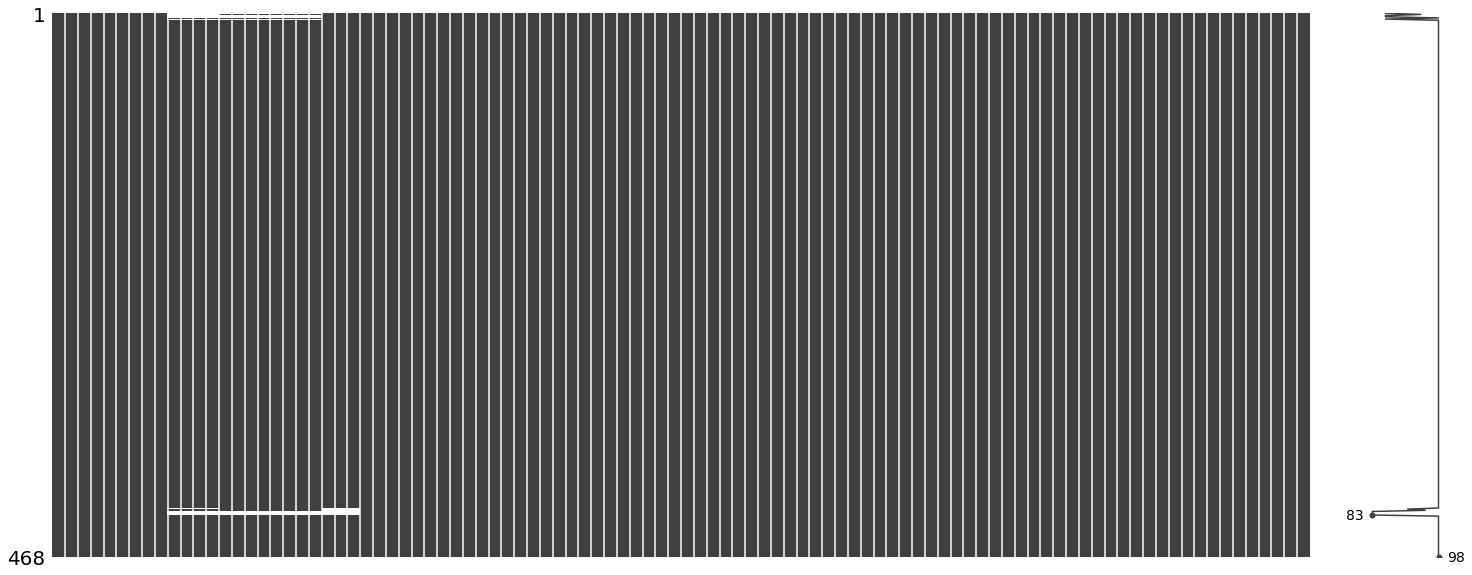

In [104]:
missingno.matrix(dataset)

In [105]:
df_economics = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Economics_Processed.csv', encoding = enc)

In [106]:
df_economics

,NUTS3_CODE,YEAR,MIO_EUR
0,EL301,2000,10002.350000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1087,EL653,2016,3040.690000
1088,EL653,2017,3112.330000
1089,EL653,2018,3111.770000
1090,EL653,2019,3210.420000


In [107]:
df_economics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [108]:
df_economics

,NUTS3_ID,year,MIO_EUR
0,EL301,2000,10002.350000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1087,EL653,2016,3040.690000
1088,EL653,2017,3112.330000
1089,EL653,2018,3111.770000
1090,EL653,2019,3210.420000


In [109]:
dataset = pd.merge(dataset, df_economics,  how='left', on=['NUTS3_ID', 'year'])

<AxesSubplot:>

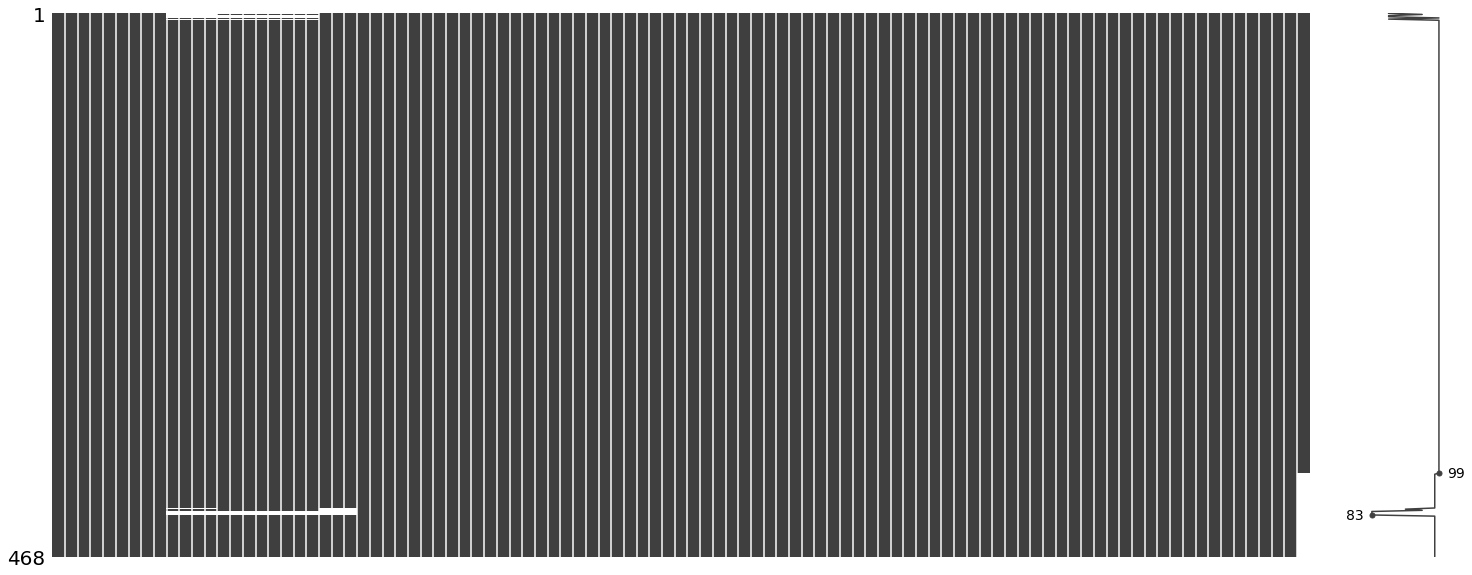

In [110]:
missingno.matrix(dataset)

In [111]:
df_trade = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Trade_Processed.csv', encoding = enc)

In [112]:
df_trade

,NUTS3_CODE,YEAR,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
714,EL653,2017,3065.000000,3506.000000
715,EL653,2018,2358.000000,2885.000000
716,EL653,2019,2914.000000,3549.000000
717,EL653,2020,4062.000000,4514.000000


In [113]:
df_trade.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [114]:
df_trade

,NUTS3_ID,year,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
714,EL653,2017,3065.000000,3506.000000
715,EL653,2018,2358.000000,2885.000000
716,EL653,2019,2914.000000,3549.000000
717,EL653,2020,4062.000000,4514.000000


In [115]:
dataset = pd.merge(dataset, df_trade,  how='left', on=['NUTS3_ID', 'year'])

<AxesSubplot:>

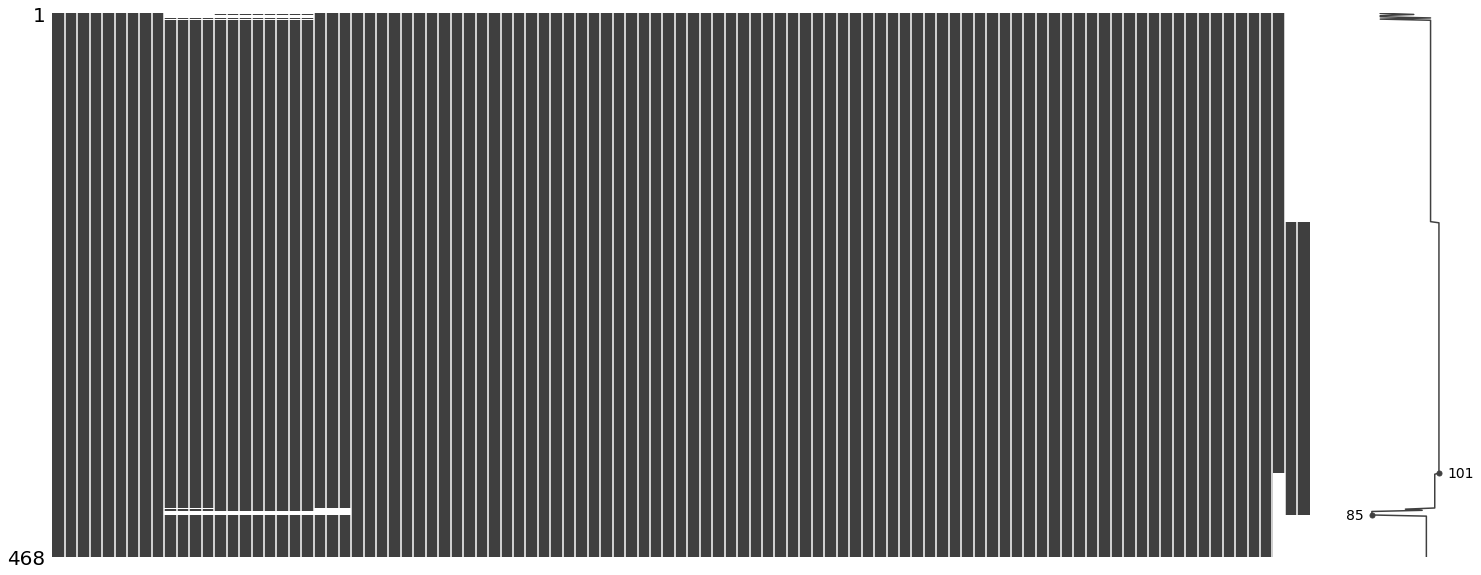

In [116]:
missingno.matrix(dataset)

In [117]:
missing = describe_dataframe(dataset)

In [118]:
missing

,Column,Missing
0,dt_placement,0.000000
1,NUTS2_ID,0.000000
2,NUTS2_NAME,0.000000
3,NUTS3_ID,0.000000
4,NUTS3_NAME,0.000000
...,...,...
96,F_Y_GE65,0.000000
97,F_TOTAL,0.000000
98,MIO_EUR,15.384600
99,L_TOTAL,46.153800


In [119]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2010-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.195364,1.570202,3.882783,6.690820,98.865052,23203.497284,1321.352593,14.861592,164.292151,614.262789,178.601039,0.031194,105.223672,0.000000,17.263686,0,18.435249,89.042099,144.067550,0.000000,1.000000,43609.055065,3375.269289,42,284.268894,1585.629960,234.678996,1.126890,1777.415878,11862.022706,952.705549,11.851873,55.244221,454.990779,15.862025,0.185197,363.881368,31,20,20,12,12,4,6,7,2,-0.969514,15.761316,207.415431,0,15.333333,19.166667,46.747967,795.536792,38.000000,-3.000000,41.000000,15.000000,25.500000,25.500000,6.000000,2002.000000,348.000000,9.000000,63.000736,812.000000,142.000000,142.000000,702.000000,17404.000000,77291.000000,28372.000000,123067.000000,16953.000000,74300.000000,35601.000000,126854.000000,3007.130000,NaN,NaN
1,2010-01,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,1,2010,NaN,NaN,NaN,NaN,-0.000415,0.447462,0.591233,-0.447462,0.000366,0.008830,0.005321,0.008830,10.141210,1.954030,6.047620,3.023659,68.808664,20381.214080,1439.355988,8.689531,159.540756,385.364133,180.555457,0.000000,52.856210,3052.548676,23.462650,0,58.864690,44.477528,137.763668,0.000000,1.000000,43609.055065,3296.453316,34,274.218916,1298.005401,217.324430,0.000000,917.122996,10627.953220,973.394450,9.072833,54.718311,362.264034,11.708138,0.000000,155.830690,31,36,30,12,12,1,6,7,2,-0.715704,15.911704,93.733414,0,17.291667,21.583333,47.962963,881.233210,42.000000,-3.000000,45.000000,17.166667,28.333333,28.333333,6.666667,1371.000000,275.000000,22.000000,62.577013,550.000000,158.000000,158.000000,378.000000,23344.000000,94158.000000,25983.000000,143485.000000,22094.000000,93589.000000,31108.000000,146791.000000,4654.450000,NaN,NaN
2,2010-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.869212,39.281871,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.030960,3.318312,6.674636,4.854475,31.010417,7730.943948,1546.605403,13.375000,175.419649,384.028806,172.296053,0.000000,24.597040,1428.272189,86.731254,2,76.607080,25.935036,146.893807,0.000000,1.000000,24072.214417,3460.380927,32,287.978453,1222.255765,198.849501,0.000000,526.617503,5039.670458,1041.036612,8.060626,63.944266,315.422916,12.169145,0.000000,91.407642,22,20,20,9,9,4,1,1,2,0.040625,16.806170,150.488717,0,17.333333,19.000000,46.341463,808.571505,40.000000,-1.000000,41.000000,17.000000,27.666667,27.666667,7.833333,1243.000000,266.000000,10.000000,67.794059,476.000000,129.000000,129.000000,391.000000,15287.000000,68105.000000,17655.000000,101047.000000,14898.000000,67890.000000,22944.000000,105732.000000,3102.990000,NaN,NaN
3,2010-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,2,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.839973,1.268766,4.554370,11.087217,445.038062,23203.4972

In [120]:
dataset.reset_index(inplace=True, drop=True)

In [121]:
dataset['cases'].value_counts()

0     439
1       6
2       5
3       4
4       3
5       2
8       2
7       2
6       2
15      1
19      1
23      1
Name: cases, dtype: int64

In [122]:
dataset['cases'].sum()

149

In [123]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2010-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.195364,1.570202,3.882783,6.690820,98.865052,23203.497284,1321.352593,14.861592,164.292151,614.262789,178.601039,0.031194,105.223672,0.000000,17.263686,0,18.435249,89.042099,144.067550,0.000000,1.000000,43609.055065,3375.269289,42,284.268894,1585.629960,234.678996,1.126890,1777.415878,11862.022706,952.705549,11.851873,55.244221,454.990779,15.862025,0.185197,363.881368,31,20,20,12,12,4,6,7,2,-0.969514,15.761316,207.415431,0,15.333333,19.166667,46.747967,795.536792,38.000000,-3.000000,41.000000,15.000000,25.500000,25.500000,6.000000,2002.000000,348.000000,9.000000,63.000736,812.000000,142.000000,142.000000,702.000000,17404.000000,77291.000000,28372.000000,123067.000000,16953.000000,74300.000000,35601.000000,126854.000000,3007.130000,NaN,NaN
1,2010-01,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,1,2010,NaN,NaN,NaN,NaN,-0.000415,0.447462,0.591233,-0.447462,0.000366,0.008830,0.005321,0.008830,10.141210,1.954030,6.047620,3.023659,68.808664,20381.214080,1439.355988,8.689531,159.540756,385.364133,180.555457,0.000000,52.856210,3052.548676,23.462650,0,58.864690,44.477528,137.763668,0.000000,1.000000,43609.055065,3296.453316,34,274.218916,1298.005401,217.324430,0.000000,917.122996,10627.953220,973.394450,9.072833,54.718311,362.264034,11.708138,0.000000,155.830690,31,36,30,12,12,1,6,7,2,-0.715704,15.911704,93.733414,0,17.291667,21.583333,47.962963,881.233210,42.000000,-3.000000,45.000000,17.166667,28.333333,28.333333,6.666667,1371.000000,275.000000,22.000000,62.577013,550.000000,158.000000,158.000000,378.000000,23344.000000,94158.000000,25983.000000,143485.000000,22094.000000,93589.000000,31108.000000,146791.000000,4654.450000,NaN,NaN
2,2010-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.869212,39.281871,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.030960,3.318312,6.674636,4.854475,31.010417,7730.943948,1546.605403,13.375000,175.419649,384.028806,172.296053,0.000000,24.597040,1428.272189,86.731254,2,76.607080,25.935036,146.893807,0.000000,1.000000,24072.214417,3460.380927,32,287.978453,1222.255765,198.849501,0.000000,526.617503,5039.670458,1041.036612,8.060626,63.944266,315.422916,12.169145,0.000000,91.407642,22,20,20,9,9,4,1,1,2,0.040625,16.806170,150.488717,0,17.333333,19.000000,46.341463,808.571505,40.000000,-1.000000,41.000000,17.000000,27.666667,27.666667,7.833333,1243.000000,266.000000,10.000000,67.794059,476.000000,129.000000,129.000000,391.000000,15287.000000,68105.000000,17655.000000,101047.000000,14898.000000,67890.000000,22944.000000,105732.000000,3102.990000,NaN,NaN
3,2010-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,2,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.839973,1.268766,4.554370,11.087217,445.038062,23203.4972

In [124]:
cols = dataset.columns

In [125]:
print(cols)


Index(['dt_placement', 'NUTS2_ID', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'x',
       'y', 'month', 'year', 'ndvi',
       ...
       'M_Y15-64', 'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65',
       'F_TOTAL', 'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL'],
      dtype='object', length=101)


In [126]:
len(cols)

101

In [127]:
dataset.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2010_2022_new.csv", encoding = enc, index = False)
